In [67]:
%matplotlib widget

import matplotlib as mpl

mpl.rcParams.update(mpl.rcParamsDefault)
mpl.rcParams["figure.figsize"] = (12,4) # default figure size
mpl.rcParams['mathtext.fontset'] = 'cm' # set default font as Computer Modern
mpl.rcParams['font.family'] = 'STIXGeneral'
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.grid'] = True
mpl.rcParams['grid.alpha'] = .2
mpl.rcParams['grid.color'] = 'black'
mpl.rcParams['grid.linestyle'] = '-.'
mpl.rcParams['grid.linewidth'] = .5
mpl.rcParams['interactive'] = True # display objects as soon as they are created. plt.show() finishes interaction
mpl.rcParams['figure.autolayout'] = True # tight layout by default
mpl.rcParams['figure.frameon'] = False # suppress figure background patch (does not seems to work..)
mpl.rcParams['toolbar'] = 'toolbar2' # axes toolbar ('None','toolbar2','toolmanager')
mpl.rcParams['savefig.format'] = 'pdf'
mpl.rcParams['savefig.transparent'] = True

Declaration des variables :
---

In [68]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import xarray as xr

### Plaque Non Gaufrée : Scan_20260427_172809/
### Plaque Non Gauffrée : Scan_20260427_143526/
### Plaque Gauffrée 4*4 : Mes_Scans_AD3/Scan_20260428_090454/

chemin_fichier_nc = "/home/adm-discohbot/Documents/Stage_Recherche_M2_Arthur/Mes_Scans_AD3/Scan_20260427_143526/donnees_completes.nc"
ds = xr.open_dataset(chemin_fichier_nc, engine="netcdf4")

SiS = ds["signal_mesure"].values        # Matrice 3D (X, Y, Temps)
SiE = ds["signal_source"].values        # Matrice 3D (X, Y, Temps)
per = 10.0
x_value = ds["x"].values 
y_value = ds["y"].values
t = ds["temps"].values

num_time_steps = len(t)
nb_x = len(x_value)
nb_y = len(y_value)
sample_frequency = ds.attrs.get("sample_frequency_Hz", num_time_steps)

vx, vy = np.meshgrid(x_value, y_value, indexing='ij')

nb_aver = 5
step_time = num_time_steps // nb_aver

freqs = np.fft.rfftfreq(step_time, d=1/sample_frequency)

N = len(freqs)  # Nombre de fréquences positives (incluant la DC)

Variables en Temps :
---

SiS_temp shape = (22, 22, 42600, 5)


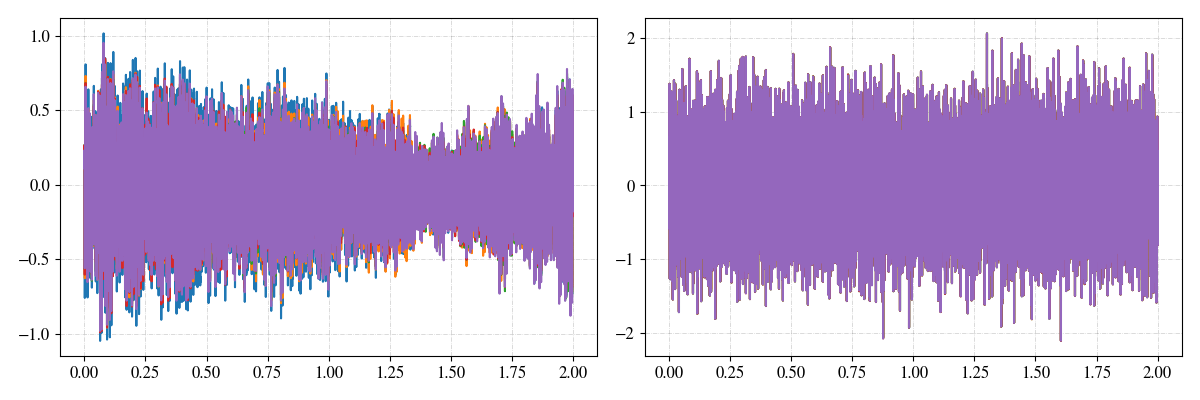

In [ ]:
SiS_temp = np.reshape(SiS ,newshape = (nb_x, nb_y ,step_time , -1) , order="F")
SiE_temp =np.reshape(SiE , newshape = (nb_x, nb_y ,step_time , -1) , order="F")

print(f"SiS_temp shape = {SiS_temp.shape}")

fig = plt.figure(num = "Response Temporel")
ax_S = fig.add_subplot(121)
t = np.linspace(0 , per / nb_aver , step_time)
S_1010 = SiS_temp[1,1,:,:]
ax_S.plot(t , S_1010 )

ax_E = fig.add_subplot(122,sharex = ax_S)
E_1010 = SiE_temp[1,1,:,:] 
ax_E.plot(t , E_1010)
plt.show()


Analyse Spectral Brut :
---

SiS_FFT shape = (22, 22, 21301, 5)


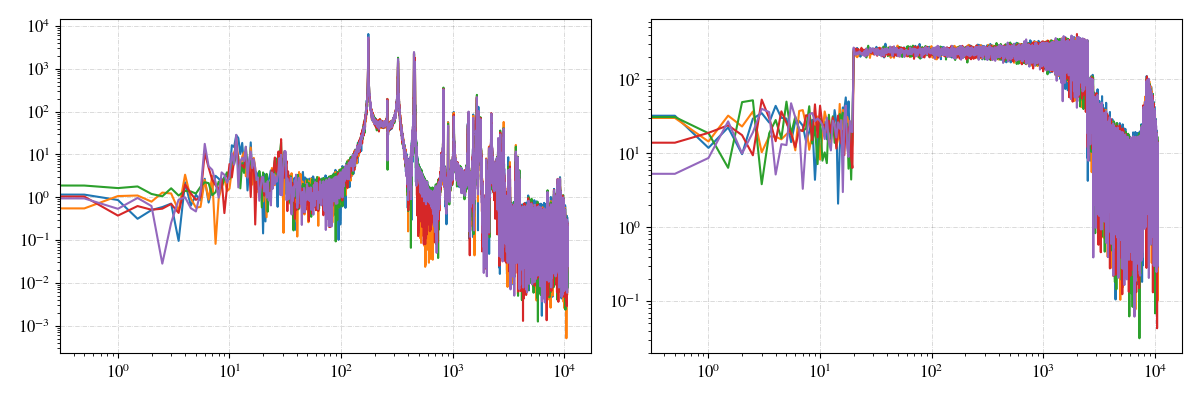

In [ ]:
SiS_FFT = np.fft.rfft(SiS_temp , axis = 2)
SiE_FFT = np.fft.rfft(SiE_temp , axis = 2)

print(f"SiS_FFT shape = {SiS_FFT.shape}")

fig = plt.figure(num = "Analyse Spectral Point n°1_1 sans moyennage")
ax_S = fig.add_subplot(121)

S_1010 = np.abs(SiS_FFT[1,1,:,:])
ax_S.loglog(freqs , S_1010 )

ax_E = fig.add_subplot(122)
E_1010 = np.abs(SiE_FFT[1,1,:,:])
ax_E.loglog(freqs , E_1010)
plt.show()

SiS_FFT shape = (22, 22, 21301)


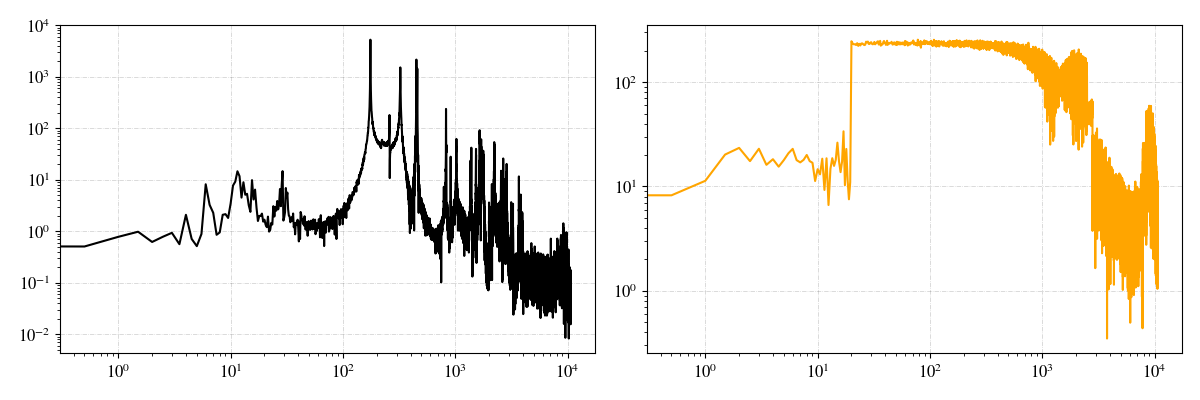

In [71]:
S_FFT_Mean = np.sqrt(np.mean(SiS_FFT**2 , axis=3))
E_FFT_Mean = np.sqrt(np.mean(SiE_FFT**2 , axis=3))

print(f"SiS_FFT shape = {S_FFT_Mean.shape}")

fig = plt.figure()
ax_S = fig.add_subplot(121)

S_1010 = np.abs(S_FFT_Mean[1,1,:])
ax_S.loglog(freqs , S_1010 ,color = 'black')

ax_E = fig.add_subplot(122)

E_1010 = np.abs(E_FFT_Mean[1,1,:])
ax_E.loglog(freqs , E_1010 ,color = 'orange')

plt.show()

(22, 22, 21301)


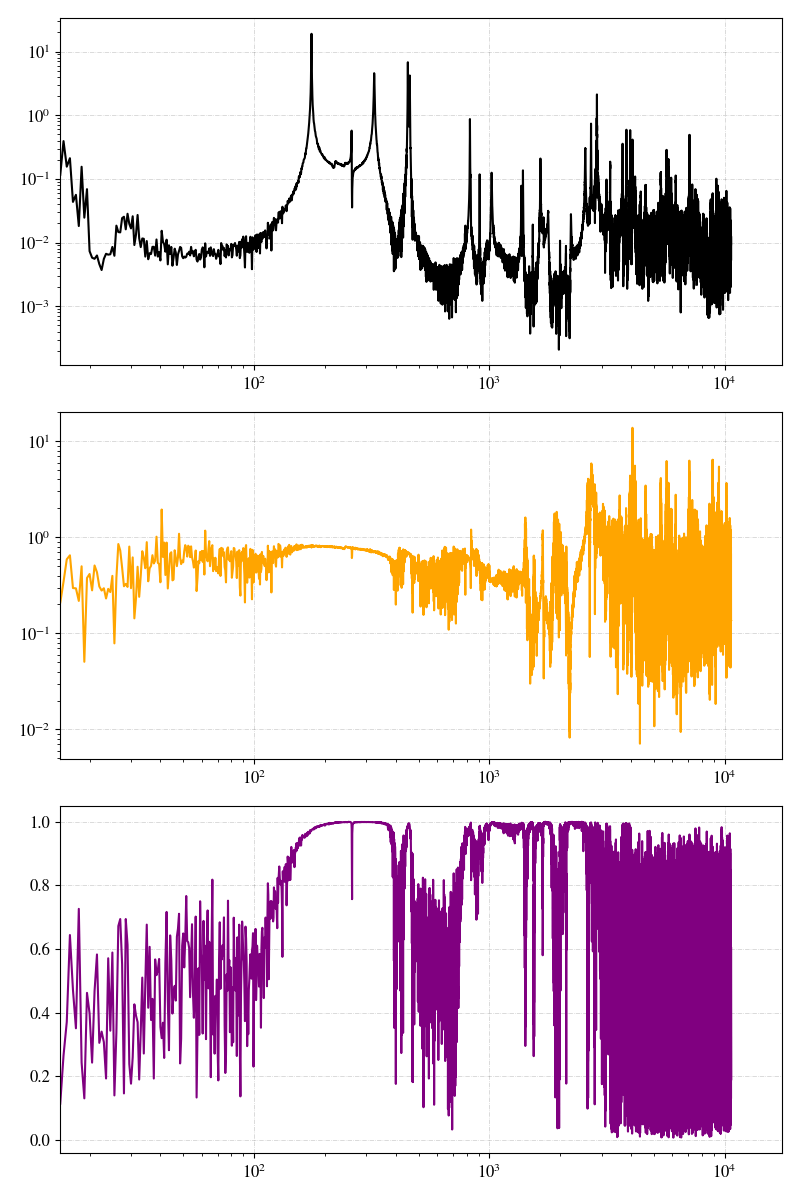

In [72]:
Sxx = (np.conjugate(SiE_FFT) * SiE_FFT) # Autospectre
Sxy = (np.conjugate(SiE_FFT) * SiS_FFT)
Syy = (np.conjugate(SiS_FFT) * SiS_FFT)

Sxx_avg = np.sqrt(np.sum(Sxx**2 , axis=3))
Sxy_avg = np.sqrt(np.sum(Sxy**2 , axis=3))
Syy_avg = np.sqrt(np.sum(Syy**2 , axis=3))

H1 = Sxy_avg / Sxx_avg 
H2 = Syy_avg / Sxy_avg

Co = H1 / H2

print(H1.shape)

fig = plt.figure(figsize=(8,12))
ax_H1 = fig.add_subplot(311)

H1_1010 = np.abs(H1[2,2,:])
ax_H1.loglog(freqs , H1_1010 ,color = 'black')

ax_H2 = fig.add_subplot(312,sharex = ax_H1)

H2_1010 = np.abs(H2[1,1,:])
ax_H2.loglog(freqs , H1_1010/H2_1010 ,color = 'orange')


ax_Co = fig.add_subplot(313,sharex = ax_H1)

ax_Co.semilogx(freqs , np.abs(Co[1,1,:]) ,color = 'purple')
ax_Co.set_xlim(15)


plt.show()


(21301,)


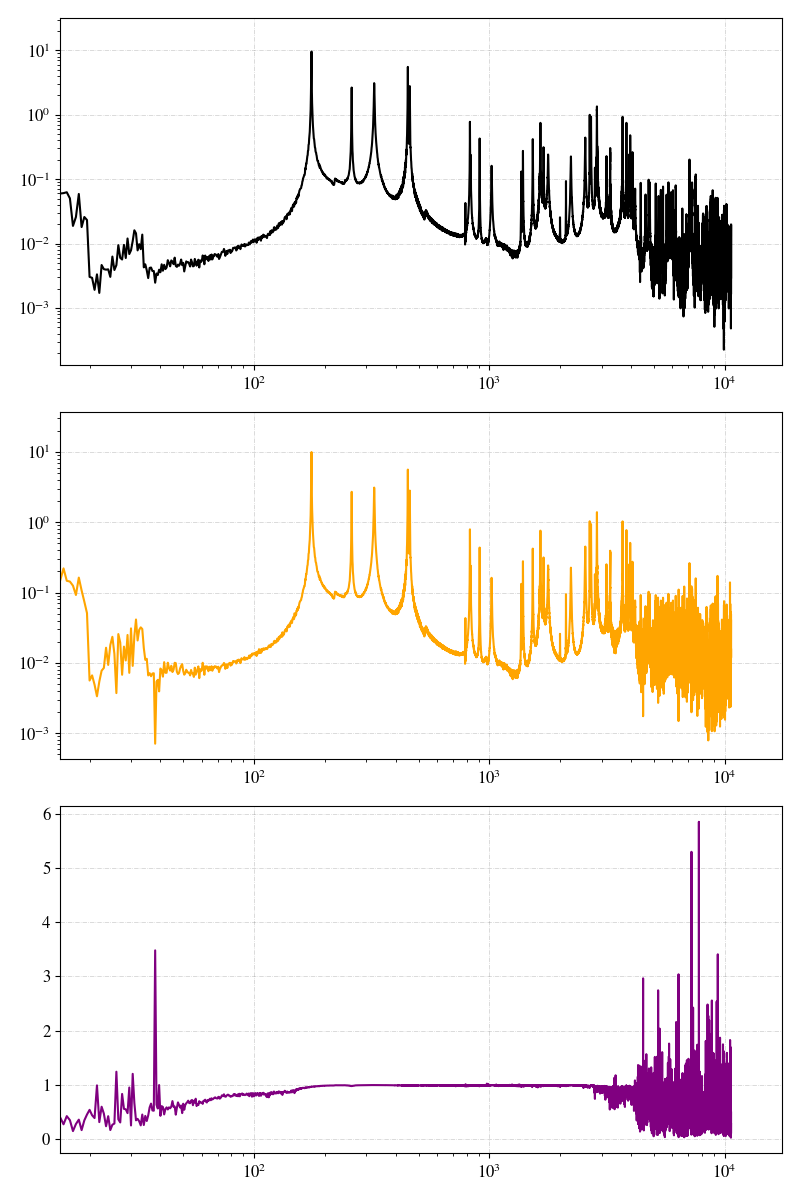

In [73]:
H1_XY = np.sqrt(np.mean(H1**2 , axis=(0,1)))
H2_XY = np.sqrt(np.mean(H2**2 , axis=(0,1)))
Co_XY = np.mean(Co,axis=(0,1),)

print(H1_XY.shape)

fig = plt.figure(figsize=(8,12))
ax_H1 = fig.add_subplot(311)

ax_H1.loglog(freqs , np.abs(H1_XY) ,color = 'black')
ax_H1.set_xlim(left = 15)

ax_H2 = fig.add_subplot(312,sharex = ax_H1)

ax_H2.loglog(freqs , np.abs(H2_XY) ,color = 'orange')
ax_H2.set_xlim(15)

ax_Co = fig.add_subplot(313,sharex = ax_H1)
Co = H1_XY / H2_XY
ax_Co.semilogx(freqs , np.abs(Co) ,color = 'purple')
ax_Co.set_xlim(15)

plt.show()

Mode Propre :
---

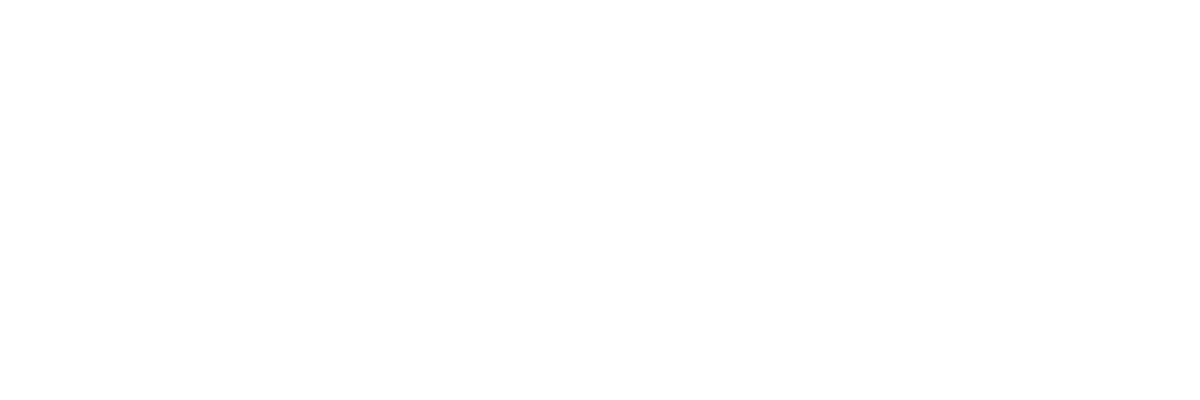

In [74]:
mode_propre = plt.figure()